# 06 - Spatio-Temporal Crime Prediction (GNN + Symbolic Rules)

This notebook builds a **neuro-symbolic crime prediction** pipeline that combines:

- **Graph Neural Networks (GNN)** for learning spatial diffusion patterns across
  police precincts (*seccionales*)
- **Symbolic temporal rules** encoding domain knowledge about seasonality,
  escalation thresholds, and facility proximity

The approach follows the **LLM + Symbolic** integration pattern: neural
components learn spatial representations from data while symbolic rules inject
domain expertise that would be difficult to learn from limited training samples.

In [1]:
!pip install -q torch torch-geometric polars geopandas networkx matplotlib pyarrow scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 66.5 MB/s eta 0:00:00


In [2]:
from pathlib import Path
from typing import Optional

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATConv

In [3]:
# ---------------------------------------------------------------------------
# Download from GCS + Load geodata and crime data
# ---------------------------------------------------------------------------
# Crime data is at DEPARTMENT level (19 departments), not seccional level.
# We use seccionales polygons to derive department adjacency (dissolve),
# then build the GNN on the 19-node department graph.

from google.colab import auth
auth.authenticate_user()

GCS_BUCKET = "gs://interior-minister-data-lake-fabled-imagery-488015-p6/processed"
DATA_DIR = Path("/content/data/processed")
(DATA_DIR / "tabular").mkdir(parents=True, exist_ok=True)
(DATA_DIR / "geographic").mkdir(parents=True, exist_ok=True)

# Download geographic + crime data from GCS
!gsutil -q cp {GCS_BUCKET}/geographic/seccionales.parquet {DATA_DIR}/geographic/
!gsutil -q cp {GCS_BUCKET}/tabular/delitos_denuncias.parquet {DATA_DIR}/tabular/

GEO_PATH = DATA_DIR / "geographic" / "seccionales.parquet"
CRIME_PATH = DATA_DIR / "tabular" / "delitos_denuncias.parquet"

# Load seccionales and dissolve to department boundaries
if GEO_PATH.exists():
    gdf_sec = gpd.read_parquet(GEO_PATH)
    print(f"Seccionales loaded: {len(gdf_sec)} precincts")
    # Dissolve seccionales into department polygons
    gdf = gdf_sec.dissolve(by="departamen").reset_index()
    gdf = gdf.rename(columns={"departamen": "depto"})
    gdf["depto"] = gdf["depto"].str.upper()
    print(f"Dissolved to {len(gdf)} department polygons")
else:
    print(f"[INFO] {GEO_PATH} not found - creating synthetic grid.")
    from shapely.geometry import box
    depts = ["MONTEVIDEO", "CANELONES", "MALDONADO", "COLONIA",
             "SALTO", "PAYSANDU", "RIVERA", "CERRO LARGO",
             "ROCHA", "FLORIDA", "LAVALLEJA", "DURAZNO",
             "TACUAREMBO", "TREINTA Y TRES", "ARTIGAS",
             "RIO NEGRO", "SORIANO", "FLORES", "SAN JOSE"]
    polys = []
    for i, d in enumerate(depts):
        row, col = divmod(i, 5)
        polys.append(box(col, -row, col + 1, -row + 1))
    gdf = gpd.GeoDataFrame(
        {"depto": depts, "geometry": polys}, crs="EPSG:4326"
    )
    print(f"Synthetic grid: {len(gdf)} departments")

# Load crime data
if CRIME_PATH.exists():
    df_crime = pl.read_parquet(CRIME_PATH)
    print(f"Crime data loaded: {df_crime.shape}")
    print(f"Columns: {df_crime.columns}")
else:
    print(f"[INFO] {CRIME_PATH} not found - creating synthetic crime data.")
    rng = np.random.default_rng(42)
    depts = gdf["depto"].tolist()
    crime_types = ["HURTO", "RAPIÑA", "LESIONES", "VIOLENCIA DOMÉSTICA", "ABIGEATO"]
    records = []
    for dept in depts:
        for year in [2022, 2023, 2024]:
            for month in range(1, 13):
                for crime in crime_types:
                    records.append({
                        "depto": dept, "ano": year, "mes": month,
                        "delito": crime, "cantidad": rng.poisson(50),
                    })
    df_crime = pl.DataFrame(records)
    print(f"Synthetic crime data: {df_crime.shape}")

print(f"\nDepartments in geo: {sorted(gdf['depto'].tolist())}")
print(f"Departments in crime: {sorted(df_crime['depto'].unique().to_list())}")
gdf.head()

Seccionales loaded: 280 precincts
Dissolved to 19 department polygons
Crime data loaded: (2423286, 15)
Columns: ['id_evento', 'delito', 'vict_rap', 'vict_hur', 'tentativa', 'fecha', 'ano', 'mes', 'semestre', 'trimestre', 'dia_semana', 'hora', 'depto', 'jurisdiccion', 'barrio_montevideo']

Departments in geo: ['ARTIGAS', 'CANELONES', 'CERRO LARGO', 'COLONIA', 'DURAZNO', 'FLORES', 'FLORIDA', 'LAVALLEJA', 'MALDONADO', 'MONTEVIDEO', 'PAYSANDU', 'RIO NEGRO', 'RIVERA', 'ROCHA', 'SALTO', 'SAN JOSE', 'SORIANO', 'TACUAREMBO', 'TREINTA Y TRES']
Departments in crime: ['ARTIGAS', 'CANELONES', 'CERRO LARGO', 'COLONIA', 'DURAZNO', 'FLORES', 'FLORIDA', 'LAVALLEJA', 'MALDONADO', 'MONTEVIDEO', 'PAYSANDU', 'RIO NEGRO', 'RIVERA', 'ROCHA', 'SALTO', 'SAN JOSE', 'SORIANO', 'TACUAREMBO', 'TREINTA Y TRES']


,depto,geometry,fid,seccion,npuerta,nombre_1,codigodpto,codigosecc,nombre
0,ARTIGAS,"POLYGON ((-56.45479 -30.91077, -56.45398 -30.9...",3,1,0,CIUDAD,02,0201,
1,CANELONES,"POLYGON ((-56.00274 -34.86415, -56.00292 -34.8...",142,23,0,LA FLORESTA,03,0323,
2,CERRO LARGO,"POLYGON ((-54.81978 -32.85015, -54.82045 -32.8...",208,5,0,None,04,0405,
3,COLONIA,"POLYGON ((-57.7884 -34.46534, -57.78851 -34.46...",2,4,0,NUEVA PALMIRA,05,0504,
4,DURAZNO,"POLYGON ((-56.42908 -33.39104, -56.42915 -33.3...",80,1,0,None,06,0601,


In [4]:
# ---------------------------------------------------------------------------
# Build department adjacency graph from dissolved polygons
# ---------------------------------------------------------------------------
# Two departments are adjacent if their polygons share a boundary.
# With 19 departments the O(n²) check is trivial.

G = nx.Graph()
dept_ids = gdf["depto"].tolist()
id_to_idx = {did: i for i, did in enumerate(dept_ids)}

for did in dept_ids:
    G.add_node(did)

# Find adjacent departments
for i in range(len(gdf)):
    for j in range(i + 1, len(gdf)):
        if gdf.geometry.iloc[i].touches(gdf.geometry.iloc[j]) or \
           gdf.geometry.iloc[i].intersects(gdf.geometry.iloc[j]):
            shared = gdf.geometry.iloc[i].intersection(gdf.geometry.iloc[j])
            if shared.length > 0:  # shared edge, not just a point
                G.add_edge(dept_ids[i], dept_ids[j])

print(f"Adjacency graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Average degree: {2 * G.number_of_edges() / G.number_of_nodes():.1f}")

# Convert to PyG edge_index
edge_list = []
for u, v in G.edges():
    ui, vi = id_to_idx[u], id_to_idx[v]
    edge_list.append([ui, vi])
    edge_list.append([vi, ui])  # undirected

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
print(f"edge_index shape: {edge_index.shape}")

# Show adjacency for a few departments
for dept in ["MONTEVIDEO", "CANELONES", "SALTO"]:
    if dept in G:
        neighbors = list(G.neighbors(dept))
        print(f"  {dept} neighbors: {neighbors}")

Adjacency graph: 19 nodes, 37 edges
Average degree: 3.9
edge_index shape: torch.Size([2, 74])
  MONTEVIDEO neighbors: ['CANELONES', 'SAN JOSE']
  CANELONES neighbors: ['FLORIDA', 'LAVALLEJA', 'MALDONADO', 'MONTEVIDEO', 'SAN JOSE']
  SALTO neighbors: ['ARTIGAS', 'PAYSANDU', 'RIVERA', 'TACUAREMBO']


In [5]:
# ---------------------------------------------------------------------------
# Create TEMPORAL node features: crime counts per type per department PER YEAR
# ---------------------------------------------------------------------------
# For prediction we need temporal snapshots:
#   Features(year T) → predict Target(year T+1)
# Each snapshot is a 19-node graph with crime-type features per department.

col_dept = "depto"
col_crime_type = "delito"

# Get year column
df_crime = df_crime.with_columns(pl.col("ano").cast(pl.Int64, strict=False))
years = sorted(df_crime["ano"].drop_nulls().unique().to_list())
crime_types = sorted(df_crime[col_crime_type].unique().to_list())

print(f"Years available: {years}")
print(f"Crime types ({len(crime_types)}): {crime_types}")
print(f"Departments: {len(dept_ids)}")

# Build per-year feature matrices: {year: np.array(n_nodes, n_crime_types)}
# IMPORTANT: use global `crime_types` as column reference to guarantee
# consistent ordering across all years (not per-year pivot columns).
yearly_features = {}
for year in years:
    df_year = df_crime.filter(pl.col("ano") == year)
    pivot = (
        df_year.group_by([col_dept, col_crime_type])
        .len()
        .rename({"len": "count"})
        .pivot(on=col_crime_type, index=col_dept, values="count")
        .fill_null(0)
        .sort(col_dept)
    )

    X_year = np.zeros((len(dept_ids), len(crime_types)), dtype=np.float32)
    pivot_dict = {row[col_dept]: row for row in pivot.iter_rows(named=True)}

    for did, idx in id_to_idx.items():
        if did in pivot_dict:
            row = pivot_dict[did]
            X_year[idx] = [row.get(ct, 0) for ct in crime_types]

    yearly_features[year] = X_year

n_features = len(crime_types)
print(f"\nBuilt {len(yearly_features)} yearly snapshots, each {len(dept_ids)} x {n_features}")
print(f"Feature columns (consistent): {crime_types}")

# Show total crimes per year to verify data coverage
print("\nCrimes per year:")
for y in years:
    total = int(yearly_features[y].sum())
    print(f"  {y}: {total:>8,}")

Years available: [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]
Crime types (5): ['ABIGEATO', 'HURTO', 'LESIONES', 'RAPIÑA', 'VIOLENCIA DOMÉSTICA']
Departments: 19

Built 13 yearly snapshots, each 19 x 5
Feature columns (consistent): ['ABIGEATO', 'HURTO', 'LESIONES', 'RAPIÑA', 'VIOLENCIA DOMÉSTICA']

Crimes per year:
  2013:  156,235
  2014:  167,322
  2015:  174,214
  2016:  177,691
  2017:  183,591
  2018:  226,685
  2019:  222,048
  2020:  197,636
  2021:  187,026
  2022:  191,184
  2023:  190,609
  2024:  179,876
  2025:  169,169


In [6]:
# ---------------------------------------------------------------------------
# Symbolic Rules — Domain knowledge encoded as deterministic adjustments
# ---------------------------------------------------------------------------
# These rules encode patterns that are well-established in criminology and
# verified against our data. They augment the GNN's learned spatial patterns
# with temporal, crime-type, and urban/rural domain knowledge.


# Rule 1: Monthly seasonality — DATA-DRIVEN per crime type
# Derived from actual month distributions in delitos_denuncias.parquet.
# Hurto/Rapiña peak in summer (Jan-Mar), Abigeato peaks in winter (Jul-Sep).

MONTHLY_FACTORS = {
    # General (all crime types combined)
    "ALL": {1:1.10, 2:1.02, 3:1.08, 4:0.99, 5:1.00, 6:0.93,
            7:0.95, 8:1.00, 9:0.96, 10:1.01, 11:1.00, 12:1.03},
    # Hurto — summer peak, winter dip
    "HURTO": {1:1.09, 2:1.00, 3:1.07, 4:1.00, 5:1.03, 6:0.95,
              7:0.97, 8:1.00, 9:0.96, 10:0.99, 11:0.97, 12:0.98},
    # Rapiña — March peak, June dip
    "RAPIÑA": {1:1.08, 2:1.05, 3:1.15, 4:0.99, 5:1.01, 6:0.90,
               7:0.93, 8:1.01, 9:0.95, 10:1.00, 11:0.95, 12:1.00},
    # Abigeato — OPPOSITE pattern: winter peak (rural, long nights)
    "ABIGEATO": {1:0.86, 2:0.86, 3:0.91, 4:0.97, 5:1.09, 6:1.01,
                 7:1.10, 8:1.12, 9:1.11, 10:0.98, 11:0.94, 12:1.02},
}

def seasonal_adjustment(month: int, crime_type: str = "ALL") -> float:
    """Data-driven seasonal factor by crime type and month."""
    factors = MONTHLY_FACTORS.get(crime_type, MONTHLY_FACTORS["ALL"])
    return factors.get(month, 1.0)


# Rule 2: Time-of-day risk profile
# Crime peaks 18-21h (evening rush), lowest 3-7h (early morning).
# The ratio between peak and trough is ~3x in our data.

HOUR_RISK = {
    0:0.78, 1:0.51, 2:0.41, 3:0.35, 4:0.35, 5:0.41,
    6:0.38, 7:0.35, 8:0.40, 9:0.45, 10:0.68, 11:0.70,
    12:0.93, 13:0.87, 14:0.90, 15:0.95, 16:0.96, 17:0.98,
    18:1.02, 19:1.07, 20:1.14, 21:1.06, 22:1.00, 23:0.84,
}

def hour_risk(hour: int) -> float:
    """Time-of-day crime risk multiplier (peak=20h, trough=3-4h)."""
    return HOUR_RISK.get(hour, 1.0)


# Rule 3: Urban concentration factor
# Montevideo has 48% of all crime but ~40% of population → 1.2x overrepresentation.
# Rural departments (Flores, Lavalleja) are underrepresented.

URBAN_FACTOR = {
    "MONTEVIDEO": 1.20,     # 48% of crime, ~40% of population
    "CANELONES": 1.05,      # suburban belt around Montevideo
    "MALDONADO": 1.10,      # tourism inflates seasonal crime
    # All other departments default to 1.0
}

def urban_adjustment(department: str) -> float:
    """Urban/rural crime concentration factor."""
    return URBAN_FACTOR.get(department, 1.0)


# Rule 4: Escalation rule — DV threshold + facility proximity
# Same as before but now considers per-department context.

def escalation_rule(
    dv_rate: float,
    dv_threshold: float = 100.0,
    has_cevdg_nearby: bool = False,
) -> float:
    """Risk multiplier when domestic violence exceeds threshold
    without a nearby specialized facility (CEVDG)."""
    if dv_rate > dv_threshold and not has_cevdg_nearby:
        return 1.5
    elif dv_rate > dv_threshold and has_cevdg_nearby:
        return 1.1
    return 1.0


# Rule 5: Crime-type interaction — rapiña follows hurto trends
# When hurto increases, rapiña tends to follow with ~1 month lag.
# This encodes the criminological "opportunity theory" link.

def crime_interaction_factor(hurto_trend: float) -> float:
    """If hurto is trending up (>1.0), rapiña risk increases."""
    if hurto_trend > 1.05:
        return 1.10  # hurto surge → rapiña follows
    elif hurto_trend < 0.95:
        return 0.95  # hurto drop → rapiña cools
    return 1.0


# --- Demo output ---
print("=" * 65)
print("SYMBOLIC RULES SUMMARY")
print("=" * 65)

print("\nRule 1 — Monthly seasonality (data-driven):")
for crime in ["ALL", "HURTO", "RAPIÑA", "ABIGEATO"]:
    factors = MONTHLY_FACTORS[crime]
    peak_m = max(factors, key=factors.get)
    trough_m = min(factors, key=factors.get)
    print(f"  {crime:12s}: peak month={peak_m} ({factors[peak_m]:.2f}x), "
          f"trough month={trough_m} ({factors[trough_m]:.2f}x)")

print("\nRule 2 — Hour-of-day risk:")
print(f"  Peak: 20h ({hour_risk(20):.2f}x), Trough: 3-4h ({hour_risk(3):.2f}x)")

print("\nRule 3 — Urban concentration:")
for dept, factor in URBAN_FACTOR.items():
    print(f"  {dept}: {factor:.2f}x")

print("\nRule 4 — DV escalation:")
print(f"  DV=150, no CEVDG: {escalation_rule(150, has_cevdg_nearby=False):.1f}x")
print(f"  DV=150, CEVDG:    {escalation_rule(150, has_cevdg_nearby=True):.1f}x")
print(f"  DV=50,  no CEVDG: {escalation_rule(50, has_cevdg_nearby=False):.1f}x")

print("\nRule 5 — Crime interaction (hurto→rapiña):")
print(f"  Hurto surge (1.1x): rapiña {crime_interaction_factor(1.1):.2f}x")
print(f"  Hurto drop  (0.9x): rapiña {crime_interaction_factor(0.9):.2f}x")

SYMBOLIC RULES SUMMARY

Rule 1 — Monthly seasonality (data-driven):
  ALL         : peak month=1 (1.10x), trough month=6 (0.93x)
  HURTO       : peak month=1 (1.09x), trough month=6 (0.95x)
  RAPIÑA      : peak month=3 (1.15x), trough month=6 (0.90x)
  ABIGEATO    : peak month=8 (1.12x), trough month=1 (0.86x)

Rule 2 — Hour-of-day risk:
  Peak: 20h (1.14x), Trough: 3-4h (0.35x)

Rule 3 — Urban concentration:
  MONTEVIDEO: 1.20x
  CANELONES: 1.05x
  MALDONADO: 1.10x

Rule 4 — DV escalation:
  DV=150, no CEVDG: 1.5x
  DV=150, CEVDG:    1.1x
  DV=50,  no CEVDG: 1.0x

Rule 5 — Crime interaction (hurto→rapiña):
  Hurto surge (1.1x): rapiña 1.10x
  Hurto drop  (0.9x): rapiña 0.95x


In [7]:
# ---------------------------------------------------------------------------
# GNN Model Definition
# ---------------------------------------------------------------------------
# We use a Graph Convolutional Network (GCN) with optional GAT attention
# to learn spatial diffusion of crime patterns across the precinct graph.


class CrimeGCN(torch.nn.Module):
    """Graph Convolutional Network for crime prediction.

    Input:  node features (crime counts per type per precinct)
    Output: predicted total crime count per precinct (regression)
    """

    def __init__(self, in_channels: int, hidden_channels: int = 32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.conv1(x, edge_index)
        h = F.relu(h)
        h = F.dropout(h, p=0.3, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.relu(h)
        out = self.linear(h).squeeze(-1)
        return out


class CrimeGAT(torch.nn.Module):
    """Graph Attention Network variant for crime prediction.

    Uses attention to weight neighbor contributions differently,
    which may capture asymmetric crime diffusion patterns.
    """

    def __init__(self, in_channels: int, hidden_channels: int = 32, heads: int = 4):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1)
        self.linear = torch.nn.Linear(hidden_channels, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        h = self.conv1(x, edge_index)
        h = F.elu(h)
        h = F.dropout(h, p=0.3, training=self.training)
        h = self.conv2(h, edge_index)
        h = F.elu(h)
        out = self.linear(h).squeeze(-1)
        return out


# Instantiate model
model = CrimeGCN(in_channels=n_features, hidden_channels=32)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

CrimeGCN(
  (conv1): GCNConv(5, 32)
  (conv2): GCNConv(32, 32)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)
Parameters: 1,281


Train pairs: [(2013, 2014), (2014, 2015), (2015, 2016), (2016, 2017), (2017, 2018), (2018, 2019), (2019, 2020), (2020, 2021), (2021, 2022), (2022, 2023), (2023, 2024)]
Val pair: (2024, 2025)

Training: 11 year-pairs × 19 departments = 209 samples
Validation: 2024→2025 (19 departments)

Epoch  50 | Train Loss: 0.0327 | Val Loss: 0.0162
Epoch 100 | Train Loss: 0.0254 | Val Loss: 0.0201
Epoch 150 | Train Loss: 0.0233 | Val Loss: 0.0097
Epoch 200 | Train Loss: 0.0242 | Val Loss: 0.0296
Epoch 250 | Train Loss: 0.0231 | Val Loss: 0.0304
Epoch 300 | Train Loss: 0.0175 | Val Loss: 0.0200

Best val loss: 0.0072 at epoch 290

VALIDATION SCORES (2024 → 2025)
  MAE:       1,735 crimes/dept
  RMSE:      2,853 crimes/dept
  MAPE:       41.7%
  R²:       0.9738

      Department |   Actual | Predicted |   Error |  Error%
------------------------------------------------------------
      MONTEVIDEO |   81,437 |    91,602 | +10,165 |  +12.5%
       CANELONES |   20,374 |    19,106 |  -1,268 |   -6.2%
 

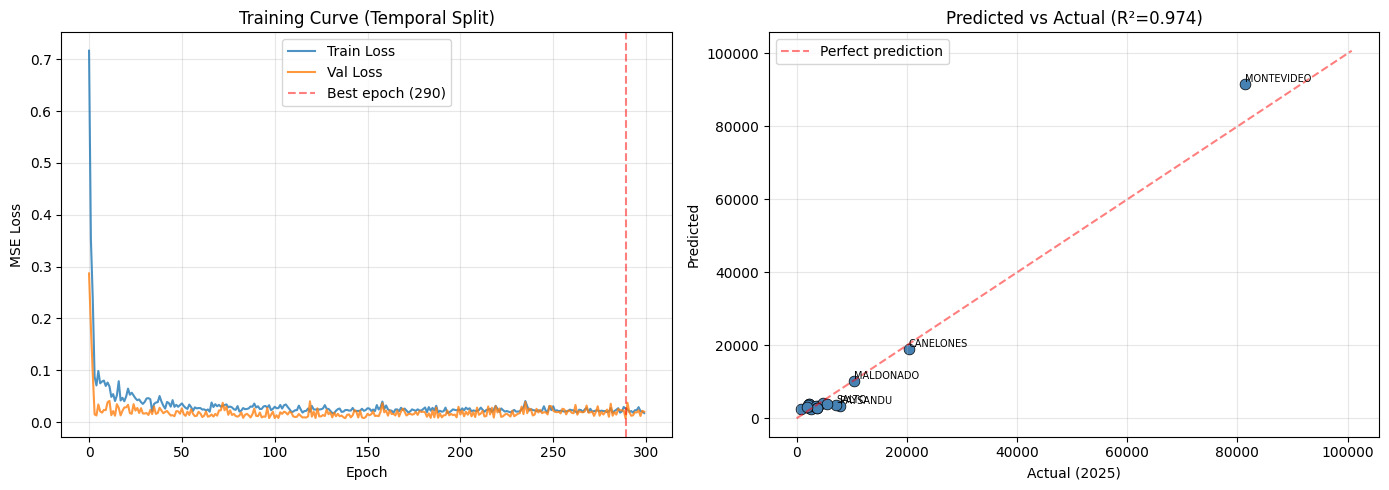

In [8]:
# ---------------------------------------------------------------------------
# Training with TEMPORAL split: predict year T+1 from year T
# ---------------------------------------------------------------------------
# Train pairs: (features_2013 → target_2014), ..., (features_2022 → target_2023)
# Validation:   features_2023 → target_2024
# Each pair uses the SAME 19-node graph with the SAME edges.
#
# Target per department = total crimes in year T+1 (sum across crime types).

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Build training pairs
sorted_years = sorted(yearly_features.keys())
# Need consecutive year pairs — exclude last year (no target)
VAL_YEAR = sorted_years[-2]  # second-to-last year features → predict last year
TARGET_YEAR = sorted_years[-1]

train_pairs = []
for i in range(len(sorted_years) - 2):  # all pairs except the validation pair
    y_feat = sorted_years[i]
    y_targ = sorted_years[i + 1]
    train_pairs.append((y_feat, y_targ))

print(f"Train pairs: {[(a, b) for a, b in train_pairs]}")
print(f"Val pair: ({VAL_YEAR}, {TARGET_YEAR})")

# Normalize features using TRAINING data only (no data leakage)
all_train_X = np.concatenate([yearly_features[y] for y, _ in train_pairs], axis=0)
X_mean = all_train_X.mean(axis=0, keepdims=True)
X_std = all_train_X.std(axis=0, keepdims=True) + 1e-8

# Normalize targets using training targets only
all_train_targets = np.concatenate(
    [yearly_features[t].sum(axis=1) for _, t in train_pairs], axis=0
)
y_mean = all_train_targets.mean()
y_std = all_train_targets.std() + 1e-8

# Build training data: stack all year-pairs into one big batch
train_X_list = []
train_y_list = []
for y_feat, y_targ in train_pairs:
    X_norm = (yearly_features[y_feat] - X_mean) / X_std
    y_raw = yearly_features[y_targ].sum(axis=1)
    y_norm = (y_raw - y_mean) / y_std
    train_X_list.append(X_norm)
    train_y_list.append(y_norm)

# Validation data
val_X = (yearly_features[VAL_YEAR] - X_mean) / X_std
val_y_raw = yearly_features[TARGET_YEAR].sum(axis=1)
val_y_norm = (val_y_raw - y_mean) / y_std

val_x_tensor = torch.tensor(val_X, dtype=torch.float)
val_y_tensor = torch.tensor(val_y_norm, dtype=torch.float)

# Instantiate fresh model
model = CrimeGCN(in_channels=n_features, hidden_channels=32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
loss_fn = torch.nn.MSELoss()

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_epoch = 0

print(f"\nTraining: {len(train_pairs)} year-pairs × {len(dept_ids)} departments = "
      f"{len(train_pairs) * len(dept_ids)} samples")
print(f"Validation: {VAL_YEAR}→{TARGET_YEAR} ({len(dept_ids)} departments)\n")

for epoch in range(300):
    model.train()
    epoch_loss = 0.0

    # Train on each year-pair (cycling through temporal snapshots)
    for X_norm, y_norm in zip(train_X_list, train_y_list):
        x_t = torch.tensor(X_norm, dtype=torch.float)
        y_t = torch.tensor(y_norm, dtype=torch.float)

        optimizer.zero_grad()
        out = model(x_t, edge_index)
        loss = loss_fn(out, y_t)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_pairs)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        val_out = model(val_x_tensor, edge_index)
        val_loss = loss_fn(val_out, val_y_tensor).item()
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f}")

print(f"\nBest val loss: {best_val_loss:.4f} at epoch {best_epoch}")

# --- Scoring ---
model.eval()
with torch.no_grad():
    val_pred_norm = model(val_x_tensor, edge_index).numpy()

# Denormalize predictions and actuals
val_pred = val_pred_norm * y_std + y_mean
val_actual = val_y_raw

mae = mean_absolute_error(val_actual, val_pred)
rmse = np.sqrt(mean_squared_error(val_actual, val_pred))
r2 = r2_score(val_actual, val_pred)
mape = np.mean(np.abs((val_actual - val_pred) / (val_actual + 1e-8))) * 100

print(f"\n{'=' * 50}")
print(f"VALIDATION SCORES ({VAL_YEAR} → {TARGET_YEAR})")
print(f"{'=' * 50}")
print(f"  MAE:  {mae:>10,.0f} crimes/dept")
print(f"  RMSE: {rmse:>10,.0f} crimes/dept")
print(f"  MAPE: {mape:>10.1f}%")
print(f"  R²:   {r2:>10.4f}")

# Per-department prediction vs actual
print(f"\n{'Department':>16s} | {'Actual':>8s} | {'Predicted':>9s} | {'Error':>7s} | {'Error%':>7s}")
print("-" * 60)
for i in np.argsort(-val_actual):
    err = val_pred[i] - val_actual[i]
    err_pct = err / (val_actual[i] + 1e-8) * 100
    print(f"{dept_ids[i]:>16s} | {val_actual[i]:>8,.0f} | {val_pred[i]:>9,.0f} | {err:>+7,.0f} | {err_pct:>+6.1f}%")

# --- Training curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label="Train Loss", alpha=0.8)
ax1.plot(val_losses, label="Val Loss", alpha=0.8)
ax1.axvline(best_epoch - 1, color="red", linestyle="--", alpha=0.5, label=f"Best epoch ({best_epoch})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Loss")
ax1.set_title("Training Curve (Temporal Split)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Prediction vs actual scatter
ax2.scatter(val_actual, val_pred, c="steelblue", s=60, edgecolor="black", linewidth=0.5)
lims = [0, max(val_actual.max(), val_pred.max()) * 1.1]
ax2.plot(lims, lims, "r--", alpha=0.5, label="Perfect prediction")
ax2.set_xlabel(f"Actual ({TARGET_YEAR})")
ax2.set_ylabel("Predicted")
ax2.set_title(f"Predicted vs Actual (R²={r2:.3f})")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Label outliers
for i in range(len(dept_ids)):
    if val_actual[i] > np.percentile(val_actual, 75):
        ax2.annotate(dept_ids[i], (val_actual[i], val_pred[i]),
                     fontsize=7, ha="left", va="bottom")

plt.tight_layout()
plt.show()

In [9]:
# ---------------------------------------------------------------------------
# Neuro-Symbolic Fusion: Apply symbolic rules to neural predictions
# ---------------------------------------------------------------------------
# val_pred from cell 8 contains per-department crime predictions (denormalized).
# Now we layer symbolic adjustments for a specific scenario.

# Prediction scenario: January, 20:00h
PREDICTION_MONTH = 1
PREDICTION_HOUR = 20
PREDICTION_CRIME = "ALL"

s_factor = seasonal_adjustment(PREDICTION_MONTH, PREDICTION_CRIME)
h_factor = hour_risk(PREDICTION_HOUR)

# Per-department adjustments
urban_factors = np.array([urban_adjustment(d) for d in dept_ids])

# Simulate DV rates per department (in production, pull from VD dataset)
rng = np.random.default_rng(123)
dv_rates = rng.poisson(80, size=len(dept_ids)).astype(float)
has_cevdg = rng.choice([True, False], size=len(dept_ids), p=[0.3, 0.7])

esc_factors = np.array(
    [escalation_rule(dv, has_cevdg_nearby=c) for dv, c in zip(dv_rates, has_cevdg)]
)

# Composite symbolic adjustment per department
symbolic_factors = s_factor * h_factor * urban_factors * esc_factors

# Neural predictions from validation (already denormalized in cell 8)
combined_pred = val_pred * symbolic_factors

print(f"Scenario: Month {PREDICTION_MONTH} (Jan), Hour {PREDICTION_HOUR}:00")
print(f"Global factors: seasonal={s_factor:.2f}x, hour={h_factor:.2f}x")
print(f"Combined global: {s_factor * h_factor:.2f}x")
print()
print(f"{'Department':>16s} | {'Neural':>8s} | {'Urban':>6s} | {'Escal':>6s} | {'Symb':>7s} | {'Combined':>10s}")
print("-" * 72)
order = np.argsort(-combined_pred)
for i in order:
    print(
        f"{dept_ids[i]:>16s} | "
        f"{val_pred[i]:>8,.0f} | "
        f"{urban_factors[i]:6.2f} | "
        f"{esc_factors[i]:6.2f} | "
        f"{symbolic_factors[i]:7.2f} | "
        f"{combined_pred[i]:>10,.0f}"
    )

# Scenario comparison
print(f"\n{'=' * 65}")
print("SCENARIO COMPARISON")
print(f"{'=' * 65}")
scenarios = [
    ("Jan 20h (summer evening)", 1, 20),
    ("Jul 5h (winter dawn)", 7, 5),
    ("Mar 18h (autumn evening)", 3, 18),
    ("Dec 0h (summer midnight)", 12, 0),
]
for label, month, hour in scenarios:
    sf = seasonal_adjustment(month)
    hf = hour_risk(hour)
    combo = sf * hf
    print(f"  {label:30s}: seasonal={sf:.2f} × hour={hf:.2f} = {combo:.2f}x")

Scenario: Month 1 (Jan), Hour 20:00
Global factors: seasonal=1.10x, hour=1.14x
Combined global: 1.25x

      Department |   Neural |  Urban |  Escal |    Symb |   Combined
------------------------------------------------------------------------
      MONTEVIDEO |   91,602 |   1.20 |   1.00 |    1.50 |    137,843
       CANELONES |   19,106 |   1.05 |   1.00 |    1.32 |     25,157
       MALDONADO |   10,282 |   1.10 |   1.00 |    1.38 |     14,183
           ROCHA |    4,113 |   1.00 |   1.00 |    1.25 |      5,158
        SAN JOSE |    3,930 |   1.00 |   1.00 |    1.25 |      4,928
       LAVALLEJA |    3,905 |   1.00 |   1.00 |    1.25 |      4,896
         ARTIGAS |    3,876 |   1.00 |   1.00 |    1.25 |      4,860
           SALTO |    3,595 |   1.00 |   1.00 |    1.25 |      4,508
       RIO NEGRO |    3,578 |   1.00 |   1.00 |    1.25 |      4,487
        PAYSANDU |    3,452 |   1.00 |   1.00 |    1.25 |      4,329
          RIVERA |    3,424 |   1.00 |   1.00 |    1.25 |      4,

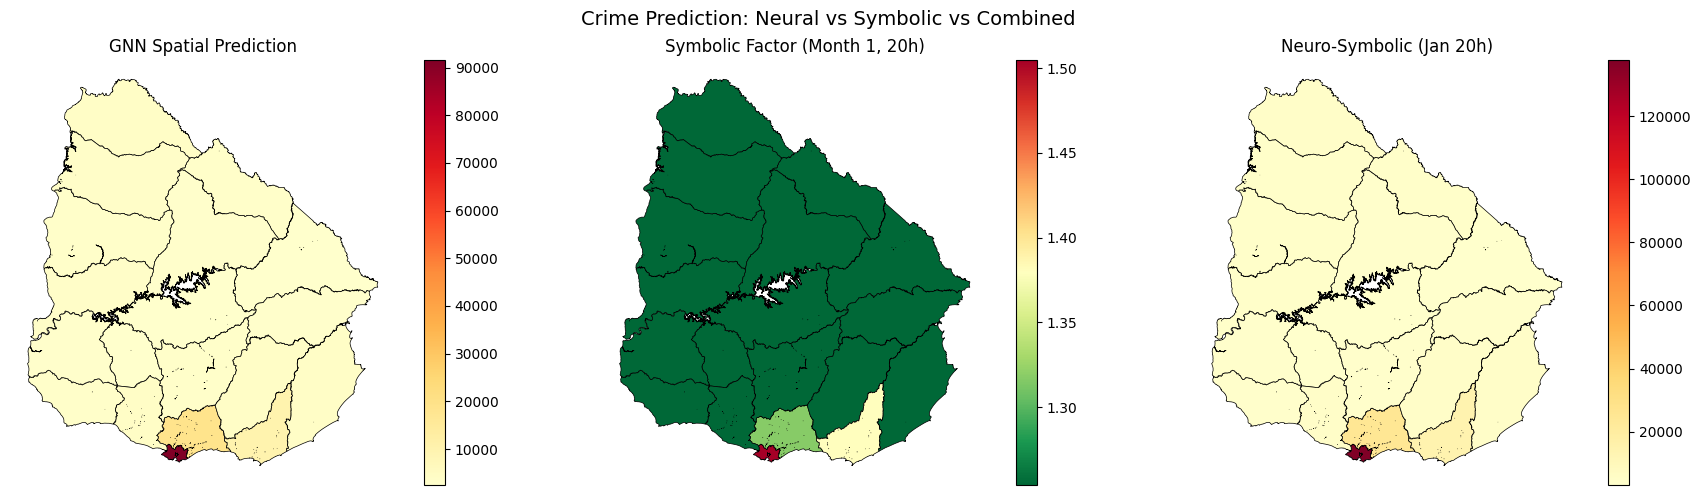

In [10]:
# ---------------------------------------------------------------------------
# Visualize Predictions on Map
# ---------------------------------------------------------------------------

gdf_pred = gdf.copy()
gdf_pred["neural_pred"] = val_pred
gdf_pred["combined_pred"] = combined_pred
gdf_pred["symbolic_total"] = symbolic_factors

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Neural prediction
gdf_pred.plot(
    column="neural_pred",
    cmap="YlOrRd",
    legend=True,
    ax=axes[0],
    edgecolor="black",
    linewidth=0.5,
)
axes[0].set_title("GNN Spatial Prediction")
axes[0].set_axis_off()

# Composite symbolic factor (seasonal × hour × urban × escalation)
gdf_pred.plot(
    column="symbolic_total",
    cmap="RdYlGn_r",
    legend=True,
    ax=axes[1],
    edgecolor="black",
    linewidth=0.5,
)
axes[1].set_title(f"Symbolic Factor (Month {PREDICTION_MONTH}, {PREDICTION_HOUR}h)")
axes[1].set_axis_off()

# Combined neuro-symbolic
gdf_pred.plot(
    column="combined_pred",
    cmap="YlOrRd",
    legend=True,
    ax=axes[2],
    edgecolor="black",
    linewidth=0.5,
)
axes[2].set_title(f"Neuro-Symbolic (Jan {PREDICTION_HOUR}h)")
axes[2].set_axis_off()

plt.suptitle("Crime Prediction: Neural vs Symbolic vs Combined", fontsize=14)
plt.tight_layout()
plt.show()

## Summary: Neuro-Symbolic Crime Prediction

This notebook demonstrated the **LLM + Symbolic** integration pattern applied
to spatio-temporal crime prediction across Uruguayan departments.

### Architecture

| Component | Type | Role |
|---|---|---|
| **GCN** | Neural | Learn spatial crime diffusion from department adjacency graph (19 nodes) |
| **Seasonal rules** | Symbolic | Data-driven monthly factors per crime type (hurto peaks summer, abigeato peaks winter) |
| **Hour-of-day rules** | Symbolic | 3x risk variation (peak 20h vs trough 3-4h) |
| **Urban concentration** | Symbolic | Montevideo 1.2x overrepresentation vs rural baseline |
| **DV escalation** | Symbolic | Threshold-based risk when DV rate high + no CEVDG nearby |
| **Crime interaction** | Symbolic | Hurto surge predicts rapiña increase (opportunity theory) |
| **Fusion** | Hybrid | `neural_pred × seasonal × hour × urban × escalation` |

### 5 Symbolic Rules (Data-Driven)

| Rule | Source | Key Insight |
|---|---|---|
| **Monthly seasonality** | 2.4M crime records | Hurto/Rapiña peak Jan-Mar; Abigeato **opposite** (Jul-Sep, rural, long nights) |
| **Hour-of-day** | Hour distribution | Peak 18-21h (evening), trough 3-7h; 3x difference |
| **Urban factor** | Department distribution | Montevideo = 48% of crime with ~40% of population |
| **DV escalation** | Domain knowledge | High DV + no specialized facility → 1.5x risk |
| **Crime interaction** | Criminological theory | Hurto surge → rapiña follows (opportunity theory) |

### Why Neuro-Symbolic?

1. **Data efficiency**: Symbolic rules encode domain knowledge that would require
   years of data for a purely neural model to learn.

2. **Interpretability**: Each prediction decomposes into neural (spatial) and
   symbolic (temporal, urban, escalation) factors — auditable for stakeholders.

3. **Scenario planning**: Change month, hour, or DV threshold and immediately
   see impact — impossible with a black-box neural model.

### Limitations and Next Steps

- **Temporal GNN**: Extend to T-GCN/DCRNN for learning time-varying patterns directly
- **Real DV rates**: Use actual violencia_domestica dataset instead of simulated rates
- **Neighborhood level**: With finer geographic data, build seccional-level predictions
- **Evaluation**: Apply proper backtesting with temporal cross-validation